# Feature importance

In [1]:
# Estimate feature importance for mpg using a simple, interpretable linear model and visualize coefficients.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [2]:
# Reuse the uploaded data and fill missing horsepower
df_mpg = pd.read_csv('data_MPG.csv')
df_mpg['horsepower'] = pd.to_numeric(df_mpg['horsepower'], errors='coerce')
df_mpg['mpg'] = pd.to_numeric(df_mpg['mpg'], errors='coerce')
df_mpg['horsepower'] = df_mpg['horsepower'].fillna(df_mpg.groupby('cylinders')['horsepower'].transform('median'))
df_mpg['horsepower'] = df_mpg['horsepower'].fillna(df_mpg['horsepower'].median())


In [3]:
feature_cols = ['horsepower', 'weight', 'acceleration', 'cylinders', 'displacement', 'model_year']
X = df_mpg[feature_cols].copy()
y = df_mpg['mpg'].copy()

In [4]:
X.head()

,horsepower,weight,acceleration,cylinders,displacement,model_year
0,130.0,3504,12.0,8,307.0,70
1,165.0,3693,11.5,8,350.0,70
2,150.0,3436,11.0,8,318.0,70
3,150.0,3433,12.0,8,304.0,70
4,140.0,3449,10.5,8,302.0,70


In [5]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [6]:
# Fit on all data for coefficient-based importance; standardization makes magnitudes comparable.
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
model.fit(X, y)
coefs = pd.Series(model.named_steps['lr'].coef_, index=feature_cols).sort_values(key=lambda s: s.abs(), ascending=False)

print(coefs)

weight         -5.903320
model_year      2.797693
displacement    0.722534
cylinders      -0.429374
acceleration    0.253884
horsepower      0.098430
dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_18540\4285754534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, palette=['#d62728' if v < 0 else '#1f77b4' for v in coefs.values])


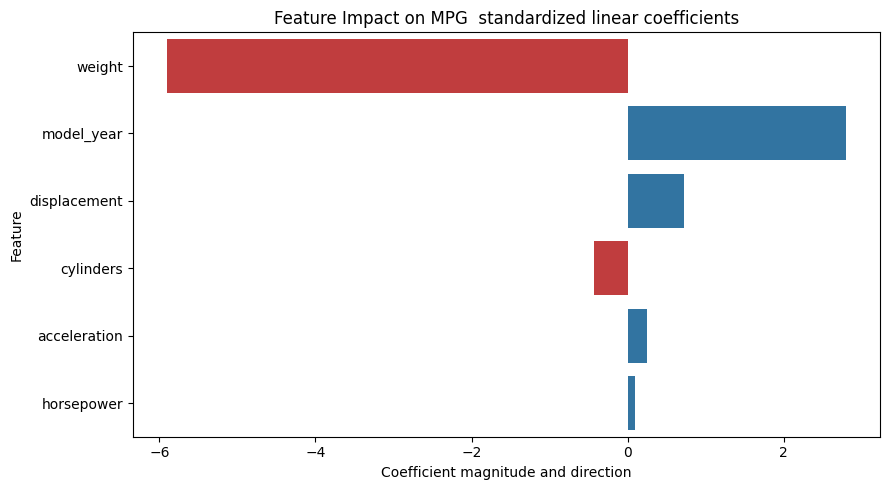

In [7]:
plt.figure(figsize=(9, 5))
sns.barplot(x=coefs.values, y=coefs.index, palette=['#d62728' if v < 0 else '#1f77b4' for v in coefs.values])
plt.title('Feature Impact on MPG  standardized linear coefficients')
plt.xlabel('Coefficient magnitude and direction')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()